In [1]:
import torch
import Emulator.Models.misc as misc
import Emulator.Inference.qg.performance as performance

In [2]:
#get the emulator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260115_162421-yenwccx3/files/checkpoint_last.p"

emu=misc.load_model(file_string).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/Emulator/Models/misc.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [3]:
from tqdm import tqdm

In [4]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/shards/qg_jet_0.pt")

data = data_dict["data"]
del data_dict

/state/partition1/job-815132/ipykernel_398091/1169674788.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/shards

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
upper_std=7.6382e-06
lower_std=3.0120e-07

if len(data.shape)==5:
    data[:,:,0,:,:]/=upper_std
    data[:,:,1,:,:]/=lower_std
else:
    data[:,0,:,:]/=upper_std
    data[:,1,:,:]/=lower_std
x = data
print(x.shape)

torch.Size([200, 100, 2, 64, 64])


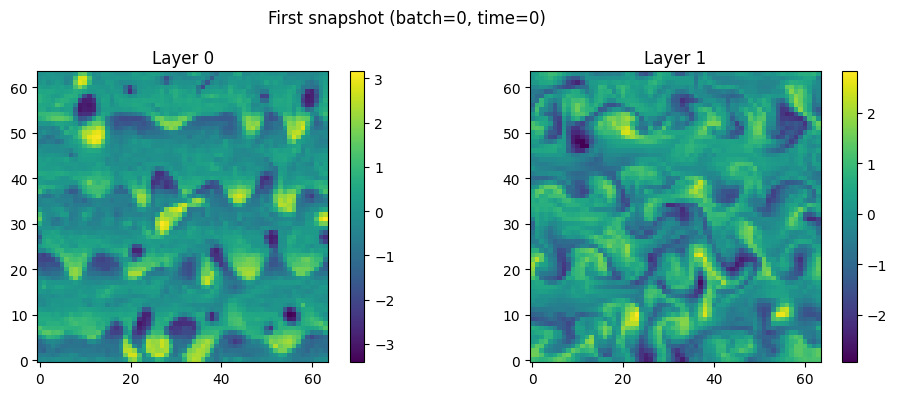

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for layer in [0, 1]:
    img = x[-1, 0, layer].detach().cpu().numpy()
    im = axes[layer].imshow(img, origin="lower")
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()


In [8]:
ics = x[-1:,0]

emu_rollout, ens, _=performance.run_emu(ics, emu, n_steps=1000, silent=False)

100%|██████████| 999/999 [00:02<00:00, 342.75it/s]


In [9]:
emu_rollout.shape

torch.Size([1, 1000, 2, 64, 64])

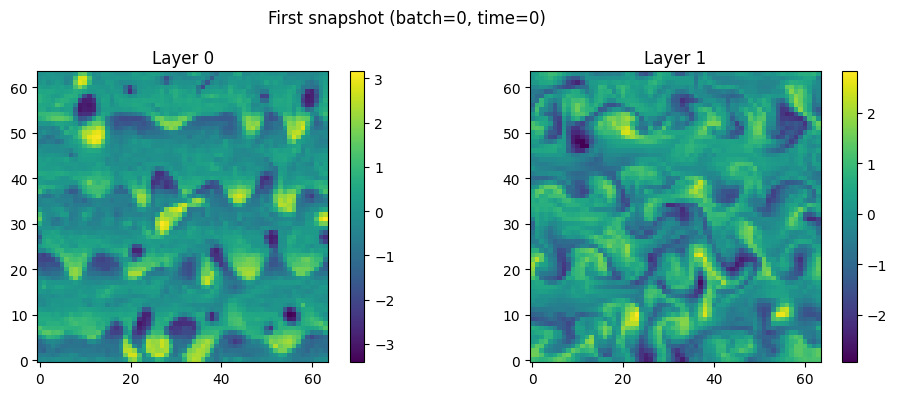

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for layer in [0, 1]:
    img = emu_rollout[-1, 0, layer].detach().cpu().numpy()
    im = axes[layer].imshow(img, origin="lower")
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()

In [11]:
import matplotlib.pyplot as plt
from matplotlib import animation
from tqdm import tqdm
import numpy as np
import cmocean

# Option A: use a self-contained ffmpeg (avoids your broken /ext3/miniforge3/bin/ffmpeg)
import matplotlib as mpl
import imageio_ffmpeg as iio

def make_movie_2layer_qg(state_vector, save_path="qg2layer_movie.mp4", fps=30,
                         vmin=None, vmax=None, stride=10,
                         layer_titles=("Layer 1", "Layer 2"),
                         share_colorbar_within_layer=True):
    """
    Create an MP4 movie from a 5D tensor of shape (B, T, 2, H, W) for 2-layer QG.

    Uses cmocean's white-red-blue diverging colormap (cmocean.cm.balance).

    Encoding:
      - Uses imageio-ffmpeg to supply a working ffmpeg binary inside Singularity.
      - Uses MPEG-4 Part 2 (codec='mpeg4') to avoid libx264 requirements.
    """

    # Point Matplotlib to the imageio-provided ffmpeg binary
    mpl.rcParams["animation.ffmpeg_path"] = iio.get_ffmpeg_exe()

    B, T, L, H, W = state_vector.shape
    assert L == 2, f"Expected 2 layers, got {L}"

    data = state_vector.detach().cpu().numpy() if hasattr(state_vector, "detach") else np.asarray(state_vector)
    frame_indices = list(range(0, T, stride))

    def _as_per_layer(x):
        if x is None:
            return [None, None]
        if np.isscalar(x):
            return [x, x]
        if len(x) == 2:
            return list(x)
        raise ValueError("vmin/vmax must be None, a scalar, or a length-2 tuple/list.")

    vmin_L = _as_per_layer(vmin)
    vmax_L = _as_per_layer(vmax)

    # If limits not provided, use symmetric limits per layer (common for QG fields)
    for l in range(2):
        if vmin_L[l] is None or vmax_L[l] is None:
            m = float(np.nanmax(np.abs(data[:, :, l])))
            vmin_L[l] = -m
            vmax_L[l] =  m

    fig, axes = plt.subplots(B, 2, figsize=(10, 4.5 * B), squeeze=False)

    ims = [[None, None] for _ in range(B)]
    for b in range(B):
        for l in range(2):
            ax = axes[b, l]
            im = ax.imshow(
                data[b, 0, l],
                cmap=cmocean.cm.balance,
                vmin=vmin_L[l],
                vmax=vmax_L[l],
                origin="upper",
            )
            ax.set_title(f"Batch {b} — {layer_titles[l]} — Timestep 0")
            ax.set_xticks([])
            ax.set_yticks([])
            ims[b][l] = im

    # Colorbars
    if share_colorbar_within_layer:
        for l in range(2):
            fig.colorbar(ims[0][l], ax=axes[:, l].ravel().tolist(), shrink=0.9)
    else:
        for b in range(B):
            for l in range(2):
                fig.colorbar(ims[b][l], ax=axes[b, l], shrink=0.9)

    def frame_generator():
        for i in tqdm(range(len(frame_indices)), desc="Building frames"):
            yield i

    def update(frame_idx):
        t = frame_indices[frame_idx]
        artists = []
        for b in range(B):
            for l in range(2):
                ims[b][l].set_data(data[b, t, l])
                axes[b, l].set_title(f"Batch {b} — {layer_titles[l]} — Timestep {t}")
                artists.append(ims[b][l])
        return artists

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frame_generator(),
        blit=False,
        repeat=False
    )

    # Use MPEG-4 Part 2 (no x264), with the working ffmpeg from imageio-ffmpeg
    Writer = animation.writers["ffmpeg"]
    writer = Writer(
        fps=fps,
        codec="mpeg4",
        bitrate=20000,
        extra_args=["-pix_fmt", "yuv420p"]
    )

    ani.save(save_path, writer=writer)
    plt.close(fig)
    print("movie saved:", save_path)


In [12]:
make_movie_2layer_qg(emu_rollout[:,:100], save_path="qg_both.mp4", stride=1, fps=30)


/state/partition1/job-815132/ipykernel_398091/3657041789.py:94: UserWarning: frames=<generator object make_movie_2layer_qg.<locals>.frame_generator at 0x151c3c429c60> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(
Building frames: 100%|██████████| 100/100 [00:18<00:00,  5.30it/s]

movie saved: qg_both.mp4


In [13]:
emu_rollout.shape

torch.Size([2, 30000, 2, 64, 64])

In [11]:
data.shape

torch.Size([1000, 100, 2, 64, 64])

In [22]:
make_movie_2layer_qg(data[-1:], save_path="qg_both.mp4", stride=1, fps=30)

/state/partition1/job-396581/ipykernel_1390951/3657041789.py:94: UserWarning: frames=<generator object make_movie_2layer_qg.<locals>.frame_generator at 0x14c9b83df970> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(
Building frames: 100%|██████████| 100/100 [00:21<00:00,  4.76it/s]

movie saved: qg_both.mp4
